    ## Импорт библиотек

In [46]:
import pandas as pd
import string
import re
import nltk
import pymorphy3

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df = pd.read_csv("petitions.csv")

In [3]:
df.head()

,id,public_petition_text,reason_category
0,3168490,снег на дороге,Благоустройство
1,3219678,очистить кабельный киоск от рекламы,Благоустройство
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД
4,3336285,Граффити,Благоустройство


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59889 entries, 0 to 59888
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    59889 non-null  int64 
 1   public_petition_text  59889 non-null  object
 2   reason_category       59889 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


## Предарительная обработка данных

In [5]:
def remove_punctuation(text): 
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text): 
    return ''.join([i if not i.isdigit() else ' ' for i in text])

def remove_multiple_spaces(text): 
    return re.sub(r'\s+', ' ', text, flags=re.I)

st = '❯\xa0—«»'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [6]:
df['prep_text'] = [remove_multiple_spaces(remove_numbers(remove_othersymbol(remove_punctuation(text.lower())))) for text in df['public_petition_text']]

In [7]:
df.head()

,id,public_petition_text,reason_category,prep_text
0,3168490,снег на дороге,Благоустройство,снег на дороге
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...
4,3336285,Граффити,Благоустройство,граффити


In [8]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','с','своём','всем','наш', 'свой']) 

In [9]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [10]:
df['tokenize_text'] = [tokenize(text) for text in df['prep_text']]

In [11]:
df.head()

,id,public_petition_text,reason_category,prep_text,tokenize_text
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...
4,3336285,Граффити,Благоустройство,граффити,граффити


In [12]:
stemmer = SnowballStemmer("russian")

stem_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = stemmer.stem(word)
            res.append(p)
        text = " ".join(res)
        stem_list.append(text)
    except Exception as e:
        print(e)
        
df['text_stem'] = stem_list

In [13]:
df.head()

,id,public_petition_text,reason_category,prep_text,tokenize_text,text_stem
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге,снег дорог
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы,очист кабельн киоск реклам
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...,прос убра дерев кустарник котор вышл предел га...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...,неудовлетворительн состоян парадн надпис двер ...
4,3336285,Граффити,Благоустройство,граффити,граффити,граффит


In [14]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [15]:
%%time
lemm_texts_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 1min 15s
Wall time: 1min 15s


In [16]:
df['text_lemm'] = [tokenize(text) for text in df['text_lemm']]

In [17]:
df.head()

,id,public_petition_text,reason_category,prep_text,tokenize_text,text_stem,text_lemm
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге,снег дорог,снег дорога
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы,очист кабельн киоск реклам,очистить кабельный киоск реклама
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...,прос убра дерев кустарник котор вышл предел га...,просить убрать дерево кустарник выйти предел г...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...,неудовлетворительн состоян парадн надпис двер ...,неудовлетворительный состояние парадный надпис...
4,3336285,Граффити,Благоустройство,граффити,граффити,граффит,граффити


In [19]:
# Получение текстовой строки из списка слов
from wordcloud import WordCloud

def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=russian_stopwords,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

In [20]:
corpus = get_corpus(df['text_lemm'].values)

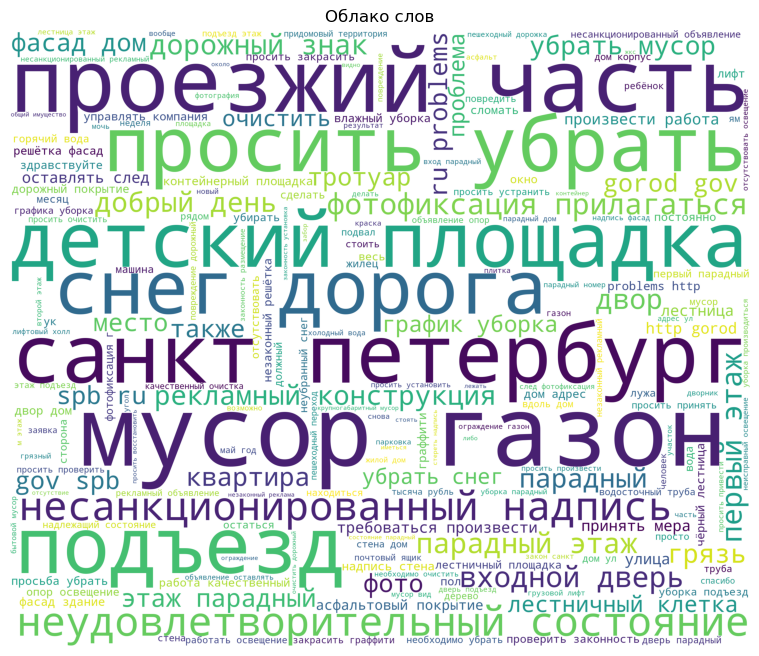

In [21]:
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Облако слов')
plt.show()
plt.close(fig)

## Тематическое моделирование

In [39]:
from sklearn.decomposition import LatentDirichletAllocation

In [22]:
vectorizer = CountVectorizer(analyzer='word', stop_words=russian_stopwords, ngram_range=(1, 3), min_df=2)
count_matrix = vectorizer.fit_transform(df['text_lemm'])

In [42]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(count_matrix)

LatentDirichletAllocation(n_components=5, random_state=42)

In [23]:
from sklearn.decomposition import TruncatedSVD

In [44]:
# вывод топ слов для каждой темы
for i, topic in enumerate(lda.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: парадный, снег, дом, вода, стена, дорога, подъезд, проблема, день, просить
Topic 1: этаж, парадный, уборка, подъезд, просить, граффити, лестница, первый, лестничный, стена
Topic 2: дверь, надпись, фасад, входной, входной дверь, решётка, ru, spb, spb ru, gorod gov spb
Topic 3: мусор, убрать, дом, газон, реклама, просить, очистить, территория, мусор газон, часть
Topic 4: дом, рекламный, площадка, объявление, покрытие, несанкционированный, надпись, конструкция, детский, требоваться


In [48]:
label_encoder = LabelEncoder()
df['cluster'] = label_encoder.fit_transform(df['reason_category'])
df

,id,public_petition_text,reason_category,prep_text,tokenize_text,text_stem,text_lemm,text_stem_tokenize,text_lemm_tokenize,cluster
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге,снег дорог,снег дорога,"[снег, дорог]","[снег, дорога]",0
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы,очист кабельн киоск реклам,очистить кабельный киоск реклама,"[очист, кабельн, киоск, реклам]","[очистить, кабельный, киоск, реклама]",0
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...,прос убра дерев кустарник котор вышл предел га...,просить убрать дерево кустарник выйти предел г...,"[прос, убра, дерев, кустарник, котор, вышл, пр...","[просить, убрать, дерево, кустарник, выйти, пр...",0
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...,неудовлетворительн состоян парадн надпис двер ...,неудовлетворительный состояние парадный надпис...,"[неудовлетворительн, состоян, парадн, надпис, ...","[неудовлетворительный, состояние, парадный, на...",11
4,3336285,Граффити,Благоустройство,граффити,граффити,граффит,граффити,[граффит],[граффити],0
...,...,...,...,...,...,...,...,...,...,...
59884,3128111,прошу закрасить граффити,Благоустройство,прошу закрасить граффити,прошу закрасить граффити,прош закрас граффит,просить закрасить граффити,"[прош, закрас, граффит]","[просить, закрасить, граффити]",0
59885,3276713,Прошу вас отремонтировать пешеходную дорожку,Благоустройство,прошу вас отремонтировать пешеходную дорожку,прошу отремонтировать пешеходную дорожку,прош отремонтирова пешеходн дорожк,просить отремонтировать пешеходный дорожка,"[прош, отремонтирова, пешеходн, дорожк]","[просить, отремонтировать, пешеходный, дорожка]",0
59886,3274663,Необходимо демонтировать незаконную рекламную ...,Незаконная информационная и (или) рекламная ко...,необходимо демонтировать незаконную рекламную ...,необходимо демонтировать незаконную рекламную ...,необходим демонтирова незакон рекламн конструкц,необходимо демонтировать незаконный рекламный ...,"[необходим, демонтирова, незакон, рекламн, кон...","[необходимо, демонтировать, незаконный, реклам...",6
59887,3359308,Очень гремит на ветру металлическая часть окна...,Кровля,очень гремит на ветру металлическая часть окна...,очень гремит ветру металлическая часть окна пр...,очен грем ветр металлическ част окн просьб убра,очень греметь ветер металлический часть окно п...,"[очен, грем, ветр, металлическ, част, окн, про...","[очень, греметь, ветер, металлический, часть, ...",3


In [50]:
cluster_to_reason = {
    cluster: reason for cluster, reason in zip(
        label_encoder.transform(label_encoder.classes_), 
        label_encoder.classes_
    )
}

## Векторизация текстовых данных

In [53]:
tfidf_vectorizer = TfidfVectorizer(max_df=1, max_features=10000000,
                                 min_df=1, stop_words=russian_stopwords,
                                 ngram_range=(1,3))

In [54]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_lemm'])

In [55]:
tfidf_matrix.shape

(59889, 441544)

## Классификация

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [56]:
X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, df['cluster'], test_size=0.2, random_state=42, stratify=df['cluster'])

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVC": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.58      1.00      0.73      6954
           1       0.00      0.00      0.00        47
           2       0.00      0.00      0.00       162
           3       0.00      0.00      0.00       165
           4       0.00      0.00      0.00        48
           5       0.00      0.00      0.00       434
           6       0.00      0.00      0.00       366
           7       0.00      0.00      0.00        50
           8       0.00      0.00      0.00       233
           9       0.00      0.00      0.00        51
          10       0.00      0.00      0.00        87
          11       0.00      0.00      0.00      2892
          12       0.00      0.00      0.00       135
          13       0.00      0.00      0.00       297
          14       0.00      0.00      0.00        57

    accuracy                           0.58     11978
   macro avg       0.04      0.07      0.05   

In [33]:
import pickle

with open('model_rf.pkl', 'wb') as f:
    pickle.dump(models['Random Forest'], f)

In [34]:
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

## Парсинг

In [35]:
from bs4 import BeautifulSoup as bs
import requests
from selenium import webdriver as wd
from selenium.webdriver.edge.service import Service

In [36]:
path = 'msedgedriver.exe'

In [37]:
service = Service(path)
options = wd.EdgeOptions()
options.add_argument('--headless')
options.add_argument('--disable-blink-features=AutomationControlled')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
driver = wd.Edge(service = service, options=options)

In [38]:
url = 'https://vmeste.permkrai.ru/problem/reports?page=1'

In [39]:
driver.get(url)

In [40]:
soup = bs(driver.page_source, 'html.parser')

In [41]:
soup

<html lang="ru"><head><meta content="csrftoken" name="csrf-token-name"/>
<meta content="184c54e835c1074b215cc811f08f4699363cdf13acdf4597e9745e0cd917247cc868f8a1a12c6438" name="csrf-token-value"/>
<meta content="Ajax-Token" name="hmac-token-name"/>
<meta charset="utf-8"/>
<meta content="msMKxShsruxrtzfncBMCi1sSuHQX04jENS9jg1XK" id="csrf" name="csrf-token"/>
<script charset="utf-8" src="/649d0e0fe7008120c7149727.js?1750732043543"></script>
<script>
      window.appLocale = 'ru';
      window.appLocaleURL = '';
    </script>
<link href="https://vmeste.permkrai.ru/favicon.ico" rel="shortcut icon" type="image/x-icon"/>
<title>Сообщения жителей</title>
<link href="/build/app.css?v=a29aca9c2b9359547803" rel="stylesheet"/>
<script defer="" src="/build/runtime.js?v=cd78a093d3505f378abd"></script>
<script defer="" src="/build/vendors.js?v=395ee2bc85fafe32e79f"></script>
<script defer="" src="/build/app.js?v=2dad8f6a4ae5903003ab"></script>
<meta content="app-id=1458156281" name="apple-itunes-app"

In [42]:
with open('vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('model_rf.pkl', 'rb') as f:
    model = pickle.load(f)

In [43]:
pagenum = 1

for i in range(1,60):
    url = f'https://vmeste.permkrai.ru/problem/reports?page={pagenum}'
    print(f'страница {pagenum}')
    driver.get(url)
    soup = bs(driver.page_source, 'html.parser')
    problems = soup.find_all('div', class_='problem-report problem-reports__body')
    
    for problem in problems:
        problem_id = problem.find('a', class_='link problem-report__title')
        problem_category = problem.find('div', class_='problem-report__category-text')
        problem_text = problem.find('div', class_='problem-report__text')
        new_row = {"id": problem_id.text.split('№')[1], "public_petition_text": problem_text.text,
                  "reason_category": problem_category.text.split(' / ')[0]}
        df.loc[len(df)] = new_row
    pagenum += 1
driver.close()

страница 1
страница 2
страница 3
страница 4
страница 5
страница 6
страница 7
страница 8
страница 9
страница 10
страница 11
страница 12
страница 13
страница 14
страница 15
страница 16
страница 17
страница 18
страница 19
страница 20
страница 21
страница 22
страница 23
страница 24
страница 25
страница 26
страница 27
страница 28
страница 29
страница 30
страница 31
страница 32
страница 33
страница 34
страница 35
страница 36
страница 37
страница 38
страница 39
страница 40
страница 41
страница 42
страница 43
страница 44
страница 45
страница 46
страница 47
страница 48
страница 49
страница 50
страница 51
страница 52
страница 53
страница 54
страница 55
страница 56
страница 57
страница 58
страница 59


In [54]:
df

,id,public_petition_text,reason_category,prep_text,tokenize_text,text_stem,text_lemm
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге,снег дорог,снег дорога
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы,очист кабельн киоск реклам,очистить кабельный киоск реклама
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...,прос убра дерев кустарник котор вышл предел га...,просить убрать дерево кустарник выйти предел г...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...,неудовлетворительн состоян парадн надпис двер ...,неудовлетворительный состояние парадный надпис...
4,3336285,Граффити,Благоустройство,граффити,граффити,граффит,граффити
...,...,...,...,...,...,...,...
60474,728016,Незаконная расклейка объявлений на опоре ВЛ 11...,Рекламные конструкции,незаконная расклейка объявлений на опоре вл кв...,незаконная расклейка объявлений опоре вл кв ко...,незакон расклейк объявлен опор вл кв координат,NaN
60475,728015,Незаконная расклейка объявлений на светофорной...,Рекламные конструкции,незаконная расклейка объявлений на светофорной...,незаконная расклейка объявлений светофорной ст...,незакон расклейк объявлен светофорн стойк коор...,NaN
60476,728014,Незаконная расклейка объявлений. Координаты 57...,Рекламные конструкции,незаконная расклейка объявлений координаты,незаконная расклейка объявлений координаты,незакон расклейк объявлен координат,NaN
60477,728013,Незаконная расклейка объявлений на фасаде. Коо...,Рекламные конструкции,незаконная расклейка объявлений на фасаде коор...,незаконная расклейка объявлений фасаде координаты,незакон расклейк объявлен фасад координат,NaN


In [57]:
%%time
lemm_texts_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

df['text_lemm'] = [tokenize(text) for text in df['text_lemm']]

CPU times: total: 1min 20s
Wall time: 1min 21s


In [58]:
X_train = tfidf.fit_transform(df['text_lemm'])
y_train = df['reason_category']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

with open(f'updated_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'updated_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)